Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Import dataset movies from https://www.kaggle.com/datasets/bharatnatrayn/movies-dataset-for-feature-extracion-prediction?select=movies.csv

In [193]:
df = pd.read_csv("movies.csv")
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,"\n Director:\nPeter Thorwarth\n| \n Stars:\nPeri Baumeister, \nCarl Anton Koch, \nAlexander Scheer, \nKais Setti\n","21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,"\n \n Stars:\nChris Wood, \nSarah Michelle Gellar, \nLena Headey, \nMark Hamill\n","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,"\n \n Stars:\nAndrew Lincoln, \nNorman Reedus, \nMelissa McBride, \nLauren Cohan\n","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits of a super scientist and his not-so-bright grandson.,"\n \n Stars:\nJustin Roiland, \nChris Parnell, \nSpencer Grammer, \nSarah Chalke\n","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of the Dead, which focuses on German safecracker Ludwig Dieter leading a group of aspiring thieves on a top secret heist during the early stages of the zombie apocalypse.","\n Director:\nMatthias Schweighöfer\n| \n Stars:\nMatthias Schweighöfer, \nNathalie Emmanuel, \nRuby O. Fee, \nStuart Martin\n",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9994,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,"\n \n Stars:\nMorgan Taylor Campbell, \nChris Cope, \nIñaki Godoy, \nRhianna Jagpal\n",NaN,NaN,NaN
9995,Arcane,(2021– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9996,Heart of Invictus,(2022– ),"\nDocumentary, Sport",NaN,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n Star:\nPrince Harry\n,NaN,NaN,NaN
9997,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,"\n Director:\nJovanka Vuckovic\n| \n Stars:\nMorgan Taylor Campbell, \nIñaki Godoy, \nRhianna Jagpal, \nSiddhartha Minhas\n",NaN,NaN,NaN


In [194]:
df.dtypes

MOVIES       object
YEAR         object
GENRE        object
RATING      float64
ONE-LINE     object
STARS        object
VOTES        object
RunTime     float64
Gross        object
dtype: object

In [195]:
df.isna().sum()

MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64

Cleaning the column YEAR and converting it to integer

In [196]:
df['YEAR'] = df['YEAR'].str.replace(r'\D','',regex = True).str[:4].replace('',np.nan).astype('Int64')
df


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,2021,"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,"\n Director:\nPeter Thorwarth\n| \n Stars:\nPeri Baumeister, \nCarl Anton Koch, \nAlexander Scheer, \nKais Setti\n","21,062",121.0,NaN
1,Masters of the Universe: Revelation,2021,"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,"\n \n Stars:\nChris Wood, \nSarah Michelle Gellar, \nLena Headey, \nMark Hamill\n","17,870",25.0,NaN
2,The Walking Dead,2010,"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,"\n \n Stars:\nAndrew Lincoln, \nNorman Reedus, \nMelissa McBride, \nLauren Cohan\n","885,805",44.0,NaN
3,Rick and Morty,2013,"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits of a super scientist and his not-so-bright grandson.,"\n \n Stars:\nJustin Roiland, \nChris Parnell, \nSpencer Grammer, \nSarah Chalke\n","414,849",23.0,NaN
4,Army of Thieves,2021,"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of the Dead, which focuses on German safecracker Ludwig Dieter leading a group of aspiring thieves on a top secret heist during the early stages of the zombie apocalypse.","\n Director:\nMatthias Schweighöfer\n| \n Stars:\nMatthias Schweighöfer, \nNathalie Emmanuel, \nRuby O. Fee, \nStuart Martin\n",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9994,The Imperfects,2021,"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,"\n \n Stars:\nMorgan Taylor Campbell, \nChris Cope, \nIñaki Godoy, \nRhianna Jagpal\n",NaN,NaN,NaN
9995,Arcane,2021,"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9996,Heart of Invictus,2022,"\nDocumentary, Sport",NaN,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n Star:\nPrince Harry\n,NaN,NaN,NaN
9997,The Imperfects,2021,"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,"\n Director:\nJovanka Vuckovic\n| \n Stars:\nMorgan Taylor Campbell, \nIñaki Godoy, \nRhianna Jagpal, \nSiddhartha Minhas\n",NaN,NaN,NaN


Removing the \n in GENRE ONE-LINE and STARS

In [197]:
df['GENRE'] = df['GENRE'].str.replace('\n','')
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\n','')
df['STARS'] = df['STARS'].str.replace('\n','')
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,2021,"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,"Director:Peter Thorwarth| Stars:Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti","21,062",121.0,NaN
1,Masters of the Universe: Revelation,2021,"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,"Stars:Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill","17,870",25.0,NaN
2,The Walking Dead,2010,"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,"Stars:Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan","885,805",44.0,NaN
3,Rick and Morty,2013,"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits of a super scientist and his not-so-bright grandson.,"Stars:Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke","414,849",23.0,NaN
4,Army of Thieves,2021,"Action, Crime, Horror",NaN,"A prequel, set before the events of Army of the Dead, which focuses on German safecracker Ludwig Dieter leading a group of aspiring thieves on a top secret heist during the early stages of the zombie apocalypse.","Director:Matthias Schweighöfer| Stars:Matthias Schweighöfer, Nathalie Emmanuel, Ruby O. Fee, Stuart Martin",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9994,The Imperfects,2021,"Adventure, Drama, Fantasy",NaN,Add a Plot,"Stars:Morgan Taylor Campbell, Chris Cope, Iñaki Godoy, Rhianna Jagpal",NaN,NaN,NaN
9995,Arcane,2021,"Animation, Action, Adventure",NaN,Add a Plot,,NaN,NaN,NaN
9996,Heart of Invictus,2022,"Documentary, Sport",NaN,Add a Plot,Director:Orlando von Einsiedel| Star:Prince Harry,NaN,NaN,NaN
9997,The Imperfects,2021,"Adventure, Drama, Fantasy",NaN,Add a Plot,"Director:Jovanka Vuckovic| Stars:Morgan Taylor Campbell, Iñaki Godoy, Rhianna Jagpal, Siddhartha Minhas",NaN,NaN,NaN


Checking if there are some duplicated rows and deleting them

In [198]:
df.duplicated().sum()

431

In [199]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

Converting the type of VOTES to integer Int64 (for nan elements)

In [200]:
df['VOTES'] = df['VOTES'].str.replace(',','').astype('Int64')
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,2021,"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,"Director:Peter Thorwarth| Stars:Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti",21062,121.0,NaN
1,Masters of the Universe: Revelation,2021,"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,"Stars:Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill",17870,25.0,NaN
2,The Walking Dead,2010,"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,"Stars:Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan",885805,44.0,NaN
3,Rick and Morty,2013,"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits of a super scientist and his not-so-bright grandson.,"Stars:Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke",414849,23.0,NaN
4,Army of Thieves,2021,"Action, Crime, Horror",NaN,"A prequel, set before the events of Army of the Dead, which focuses on German safecracker Ludwig Dieter leading a group of aspiring thieves on a top secret heist during the early stages of the zombie apocalypse.","Director:Matthias Schweighöfer| Stars:Matthias Schweighöfer, Nathalie Emmanuel, Ruby O. Fee, Stuart Martin",<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9993,Totenfrau,2022,"Drama, Thriller",NaN,Add a Plot,"Director:Nicolai Rohde| Stars:Felix Klare, Romina Küper, Anna Maria Mühe, Robert Palfrader",<NA>,NaN,NaN
9995,Arcane,2021,"Animation, Action, Adventure",NaN,Add a Plot,,<NA>,NaN,NaN
9996,Heart of Invictus,2022,"Documentary, Sport",NaN,Add a Plot,Director:Orlando von Einsiedel| Star:Prince Harry,<NA>,NaN,NaN
9997,The Imperfects,2021,"Adventure, Drama, Fantasy",NaN,Add a Plot,"Director:Jovanka Vuckovic| Stars:Morgan Taylor Campbell, Iñaki Godoy, Rhianna Jagpal, Siddhartha Minhas",<NA>,NaN,NaN


Removing the M$ in column Gross and converting it to float64 (for nan elements)

In [201]:
df['Gross'] = df['Gross'].str.replace(r'[$M]','',regex = True).astype('float64')
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,2021,"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,"Director:Peter Thorwarth| Stars:Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti",21062,121.0,NaN
1,Masters of the Universe: Revelation,2021,"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,"Stars:Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill",17870,25.0,NaN
2,The Walking Dead,2010,"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,"Stars:Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan",885805,44.0,NaN
3,Rick and Morty,2013,"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits of a super scientist and his not-so-bright grandson.,"Stars:Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke",414849,23.0,NaN
4,Army of Thieves,2021,"Action, Crime, Horror",NaN,"A prequel, set before the events of Army of the Dead, which focuses on German safecracker Ludwig Dieter leading a group of aspiring thieves on a top secret heist during the early stages of the zombie apocalypse.","Director:Matthias Schweighöfer| Stars:Matthias Schweighöfer, Nathalie Emmanuel, Ruby O. Fee, Stuart Martin",<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9993,Totenfrau,2022,"Drama, Thriller",NaN,Add a Plot,"Director:Nicolai Rohde| Stars:Felix Klare, Romina Küper, Anna Maria Mühe, Robert Palfrader",<NA>,NaN,NaN
9995,Arcane,2021,"Animation, Action, Adventure",NaN,Add a Plot,,<NA>,NaN,NaN
9996,Heart of Invictus,2022,"Documentary, Sport",NaN,Add a Plot,Director:Orlando von Einsiedel| Star:Prince Harry,<NA>,NaN,NaN
9997,The Imperfects,2021,"Adventure, Drama, Fantasy",NaN,Add a Plot,"Director:Jovanka Vuckovic| Stars:Morgan Taylor Campbell, Iñaki Godoy, Rhianna Jagpal, Siddhartha Minhas",<NA>,NaN,NaN


Removing the limit of the lines that can be shown 

In [202]:
pd.set_option('display.max_colwidth', None)
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,2021,"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,"Director:Peter Thorwarth| Stars:Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti",21062,121.0,NaN
1,Masters of the Universe: Revelation,2021,"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,"Stars:Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill",17870,25.0,NaN
2,The Walking Dead,2010,"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,"Stars:Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan",885805,44.0,NaN
3,Rick and Morty,2013,"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits of a super scientist and his not-so-bright grandson.,"Stars:Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke",414849,23.0,NaN
4,Army of Thieves,2021,"Action, Crime, Horror",NaN,"A prequel, set before the events of Army of the Dead, which focuses on German safecracker Ludwig Dieter leading a group of aspiring thieves on a top secret heist during the early stages of the zombie apocalypse.","Director:Matthias Schweighöfer| Stars:Matthias Schweighöfer, Nathalie Emmanuel, Ruby O. Fee, Stuart Martin",<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9993,Totenfrau,2022,"Drama, Thriller",NaN,Add a Plot,"Director:Nicolai Rohde| Stars:Felix Klare, Romina Küper, Anna Maria Mühe, Robert Palfrader",<NA>,NaN,NaN
9995,Arcane,2021,"Animation, Action, Adventure",NaN,Add a Plot,,<NA>,NaN,NaN
9996,Heart of Invictus,2022,"Documentary, Sport",NaN,Add a Plot,Director:Orlando von Einsiedel| Star:Prince Harry,<NA>,NaN,NaN
9997,The Imperfects,2021,"Adventure, Drama, Fantasy",NaN,Add a Plot,"Director:Jovanka Vuckovic| Stars:Morgan Taylor Campbell, Iñaki Godoy, Rhianna Jagpal, Siddhartha Minhas",<NA>,NaN,NaN


Spliting the column STARS into two : the first for the director, the second for the stars

In [203]:
def extracte_dir_st(row):
    dir_st = str(row['STARS']).split('|')
    d = dir_st[0]
    try:
        s = dir_st[1]
    except IndexError:
        s = ''
    if 'Director' in d:
        direc = d.replace('Director:','')
        star = s.replace('Stars:','')
    else:
        direc = ''
        star = d.replace('Stars:','')
    return pd.Series({'Director':direc,'Stars':star})

df[['Director','Stars']] = df.apply(extracte_dir_st,axis = 1)
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross,Director,Stars
0,Blood Red Sky,2021,"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,"Director:Peter Thorwarth| Stars:Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti",21062,121.0,NaN,Peter Thorwarth,"Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti"
1,Masters of the Universe: Revelation,2021,"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,"Stars:Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill",17870,25.0,NaN,,"Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill"
2,The Walking Dead,2010,"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,"Stars:Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan",885805,44.0,NaN,,"Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan"
3,Rick and Morty,2013,"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits of a super scientist and his not-so-bright grandson.,"Stars:Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke",414849,23.0,NaN,,"Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke"
4,Army of Thieves,2021,"Action, Crime, Horror",NaN,"A prequel, set before the events of Army of the Dead, which focuses on German safecracker Ludwig Dieter leading a group of aspiring thieves on a top secret heist during the early stages of the zombie apocalypse.","Director:Matthias Schweighöfer| Stars:Matthias Schweighöfer, Nathalie Emmanuel, Ruby O. Fee, Stuart Martin",<NA>,NaN,NaN,Matthias Schweighöfer,"Matthias Schweighöfer, Nathalie Emmanuel, Ruby O. Fee, Stuart Martin"
...,...,...,...,...,...,...,...,...,...,...,...
9993,Totenfrau,2022,"Drama, Thriller",NaN,Add a Plot,"Director:Nicolai Rohde| Stars:Felix Klare, Romina Küper, Anna Maria Mühe, Robert Palfrader",<NA>,NaN,NaN,Nicolai Rohde,"Felix Klare, Romina Küper, Anna Maria Mühe, Robert Palfrader"
9995,Arcane,2021,"Animation, Action, Adventure",NaN,Add a Plot,,<NA>,NaN,NaN,,
9996,Heart of Invictus,2022,"Documentary, Sport",NaN,Add a Plot,Director:Orlando von Einsiedel| Star:Prince Harry,<NA>,NaN,NaN,Orlando von Einsiedel,Star:Prince Harry
9997,The Imperfects,2021,"Adventure, Drama, Fantasy",NaN,Add a Plot,"Director:Jovanka Vuckovic| Stars:Morgan Taylor Campbell, Iñaki Godoy, Rhianna Jagpal, Siddhartha Minhas",<NA>,NaN,NaN,Jovanka Vuckovic,"Morgan Taylor Campbell, Iñaki Godoy, Rhianna Jagpal, Siddhartha Minhas"


Removing the STARS from the data frame (it's USLESS)

In [204]:
df.drop('STARS',axis = 1,inplace = True)
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars
0,Blood Red Sky,2021,"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,21062,121.0,NaN,Peter Thorwarth,"Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti"
1,Masters of the Universe: Revelation,2021,"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,17870,25.0,NaN,,"Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill"
2,The Walking Dead,2010,"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,885805,44.0,NaN,,"Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan"
3,Rick and Morty,2013,"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits of a super scientist and his not-so-bright grandson.,414849,23.0,NaN,,"Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke"
4,Army of Thieves,2021,"Action, Crime, Horror",NaN,"A prequel, set before the events of Army of the Dead, which focuses on German safecracker Ludwig Dieter leading a group of aspiring thieves on a top secret heist during the early stages of the zombie apocalypse.",<NA>,NaN,NaN,Matthias Schweighöfer,"Matthias Schweighöfer, Nathalie Emmanuel, Ruby O. Fee, Stuart Martin"
...,...,...,...,...,...,...,...,...,...,...
9993,Totenfrau,2022,"Drama, Thriller",NaN,Add a Plot,<NA>,NaN,NaN,Nicolai Rohde,"Felix Klare, Romina Küper, Anna Maria Mühe, Robert Palfrader"
9995,Arcane,2021,"Animation, Action, Adventure",NaN,Add a Plot,<NA>,NaN,NaN,,
9996,Heart of Invictus,2022,"Documentary, Sport",NaN,Add a Plot,<NA>,NaN,NaN,Orlando von Einsiedel,Star:Prince Harry
9997,The Imperfects,2021,"Adventure, Drama, Fantasy",NaN,Add a Plot,<NA>,NaN,NaN,Jovanka Vuckovic,"Morgan Taylor Campbell, Iñaki Godoy, Rhianna Jagpal, Siddhartha Minhas"


Dropping all rows that have nan value except in column Gross

In [205]:
df.dropna(subset=[col for col in df.columns if col != 'Gross'],inplace = True)
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars
0,Blood Red Sky,2021,"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,21062,121.0,NaN,Peter Thorwarth,"Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti"
1,Masters of the Universe: Revelation,2021,"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,17870,25.0,NaN,,"Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill"
2,The Walking Dead,2010,"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,885805,44.0,NaN,,"Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan"
3,Rick and Morty,2013,"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits of a super scientist and his not-so-bright grandson.,414849,23.0,NaN,,"Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke"
5,Outer Banks,2020,"Action, Crime, Drama",7.6,A group of teenagers from the wrong side of the tracks stumble upon a treasure map that unearths a long buried secret.,25858,50.0,NaN,,"Chase Stokes, Madelyn Cline, Madison Bailey, Jonathan Daviss"
...,...,...,...,...,...,...,...,...,...,...
9959,Sexify,2021,"Comedy, Drama",6.8,"Monika's idea for gathering data is a hit, but Natalia isn't happy with the results. The girls go to a class on female pleasure to gain more insight.",108,38.0,NaN,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"
9960,Sexify,2021,"Comedy, Drama",7.1,"After facing their parents at Easter breakfast, each of the girls needs to let off some steam. Luckily, there's a wild party on the dorm's rooftop.",103,37.0,NaN,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"
9961,Sexify,2021,"Comedy, Drama",6.9,"After getting an anonymous tip about the copulation lab, the dean investigates the girls' project and threatens them with expulsion from the university.",96,40.0,NaN,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"
9962,Sexify,2021,"Comedy, Drama",7.1,The big pitch at the university tech competition is upon the girls. They'll have to decide: Are they willing to sacrifice everything to participate?,100,47.0,NaN,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"


Changing the index in the left to range index from 0 to 6778

In [206]:
df.reset_index(drop = True,inplace = True)
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars
0,Blood Red Sky,2021,"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,21062,121.0,NaN,Peter Thorwarth,"Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti"
1,Masters of the Universe: Revelation,2021,"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,17870,25.0,NaN,,"Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill"
2,The Walking Dead,2010,"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,885805,44.0,NaN,,"Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan"
3,Rick and Morty,2013,"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits of a super scientist and his not-so-bright grandson.,414849,23.0,NaN,,"Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke"
4,Outer Banks,2020,"Action, Crime, Drama",7.6,A group of teenagers from the wrong side of the tracks stumble upon a treasure map that unearths a long buried secret.,25858,50.0,NaN,,"Chase Stokes, Madelyn Cline, Madison Bailey, Jonathan Daviss"
...,...,...,...,...,...,...,...,...,...,...
6774,Sexify,2021,"Comedy, Drama",6.8,"Monika's idea for gathering data is a hit, but Natalia isn't happy with the results. The girls go to a class on female pleasure to gain more insight.",108,38.0,NaN,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"
6775,Sexify,2021,"Comedy, Drama",7.1,"After facing their parents at Easter breakfast, each of the girls needs to let off some steam. Luckily, there's a wild party on the dorm's rooftop.",103,37.0,NaN,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"
6776,Sexify,2021,"Comedy, Drama",6.9,"After getting an anonymous tip about the copulation lab, the dean investigates the girls' project and threatens them with expulsion from the university.",96,40.0,NaN,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"
6777,Sexify,2021,"Comedy, Drama",7.1,The big pitch at the university tech competition is upon the girls. They'll have to decide: Are they willing to sacrifice everything to participate?,100,47.0,NaN,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"


Filling null values in Gross with 0

In [207]:
df.fillna({'Gross':0},inplace = True)
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars
0,Blood Red Sky,2021,"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.,21062,121.0,0.0,Peter Thorwarth,"Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti"
1,Masters of the Universe: Revelation,2021,"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.,17870,25.0,0.0,,"Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill"
2,The Walking Dead,2010,"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.,885805,44.0,0.0,,"Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan"
3,Rick and Morty,2013,"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits of a super scientist and his not-so-bright grandson.,414849,23.0,0.0,,"Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke"
4,Outer Banks,2020,"Action, Crime, Drama",7.6,A group of teenagers from the wrong side of the tracks stumble upon a treasure map that unearths a long buried secret.,25858,50.0,0.0,,"Chase Stokes, Madelyn Cline, Madison Bailey, Jonathan Daviss"
...,...,...,...,...,...,...,...,...,...,...
6774,Sexify,2021,"Comedy, Drama",6.8,"Monika's idea for gathering data is a hit, but Natalia isn't happy with the results. The girls go to a class on female pleasure to gain more insight.",108,38.0,0.0,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"
6775,Sexify,2021,"Comedy, Drama",7.1,"After facing their parents at Easter breakfast, each of the girls needs to let off some steam. Luckily, there's a wild party on the dorm's rooftop.",103,37.0,0.0,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"
6776,Sexify,2021,"Comedy, Drama",6.9,"After getting an anonymous tip about the copulation lab, the dean investigates the girls' project and threatens them with expulsion from the university.",96,40.0,0.0,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"
6777,Sexify,2021,"Comedy, Drama",7.1,The big pitch at the university tech competition is upon the girls. They'll have to decide: Are they willing to sacrifice everything to participate?,100,47.0,0.0,Kalina Alabrudzinska,"Aleksandra Skraba, Maria Sobocinska, Sandra Drzymalska, Piotr Pacek"


### Visualisation
Visualizing Gross in relation to RunTime then RATING then VOTES

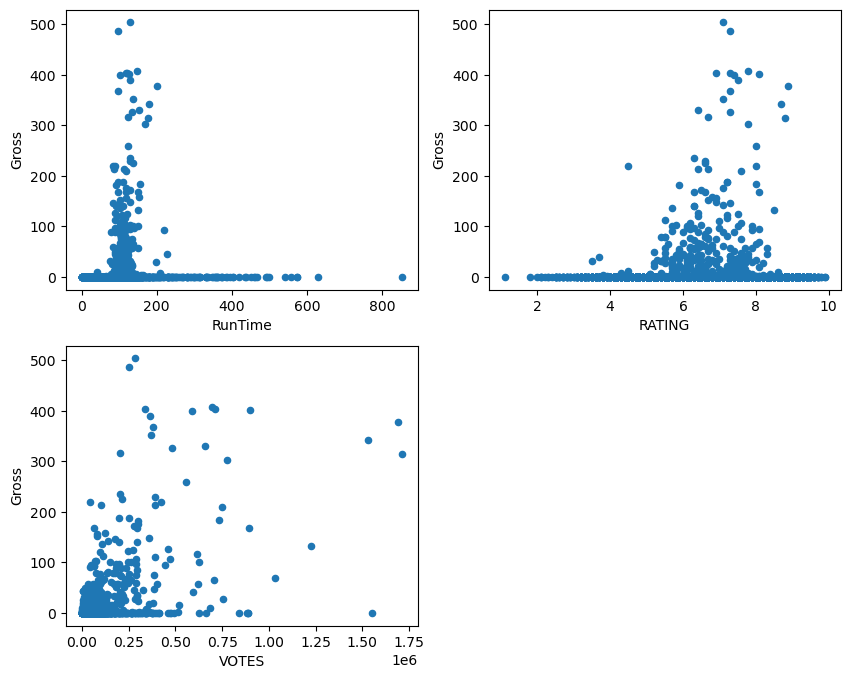

In [217]:
plt.figure(figsize=(10,8))
ax1 = plt.subplot(2,2,1)
df.plot(kind = 'scatter',x = 'RunTime',y = 'Gross',ax=ax1)
ax2 = plt.subplot(2,2,2)
df.plot(kind = 'scatter',x = 'RATING',y = 'Gross',ax=ax2)
ax3 = plt.subplot(2,2,3)
df.plot(kind = 'scatter',x = 'VOTES',y = 'Gross',ax=ax3)

plt.show()

Extracting all the existing genres 

In [ ]:
Liste_genre = []

for j in range(460):
    genres = str(df.loc[j, 'GENRE']).split(', ')
    for genre in genres:
        genre = genre.strip()
        if genre and genre not in Liste_genre:
            Liste_genre.append(genre)

print(Liste_genre)

['Action', 'Horror', 'Thriller', 'Animation', 'Adventure', 'Drama', 'Comedy', 'Crime', 'Romance', 'Mystery', 'Fantasy', 'History', 'Sci-Fi', 'Biography', 'Family', 'Documentary', 'Music', 'Sport', 'Short', 'Game-Show', 'Reality-TV', 'Musical', 'War', 'Western']


Ranking genres based on movies rating

In [ ]:
Rat = dict()

for genre in Liste_genre:
    L = []
    for i in range(460):
        genres = [g.strip() for g in str(df.loc[i, 'GENRE']).split(',')]
        if genre in genres:
            L.append(df.loc[i,'RATING'])
    Rat[genre] = np.mean(L)

Rat_sorted = dict(sorted(Rat.items(), key=lambda item: item[1], reverse=True))
Ranking = pd.Series(Rat_sorted.values(),Rat_sorted.keys())
Rat2 = dict()
Rat2['Genre'] = Rat_sorted.keys()
Rat2['Rating'] = Rat_sorted.values()

<AxesSubplot:xlabel='Rating', ylabel='Genre'>

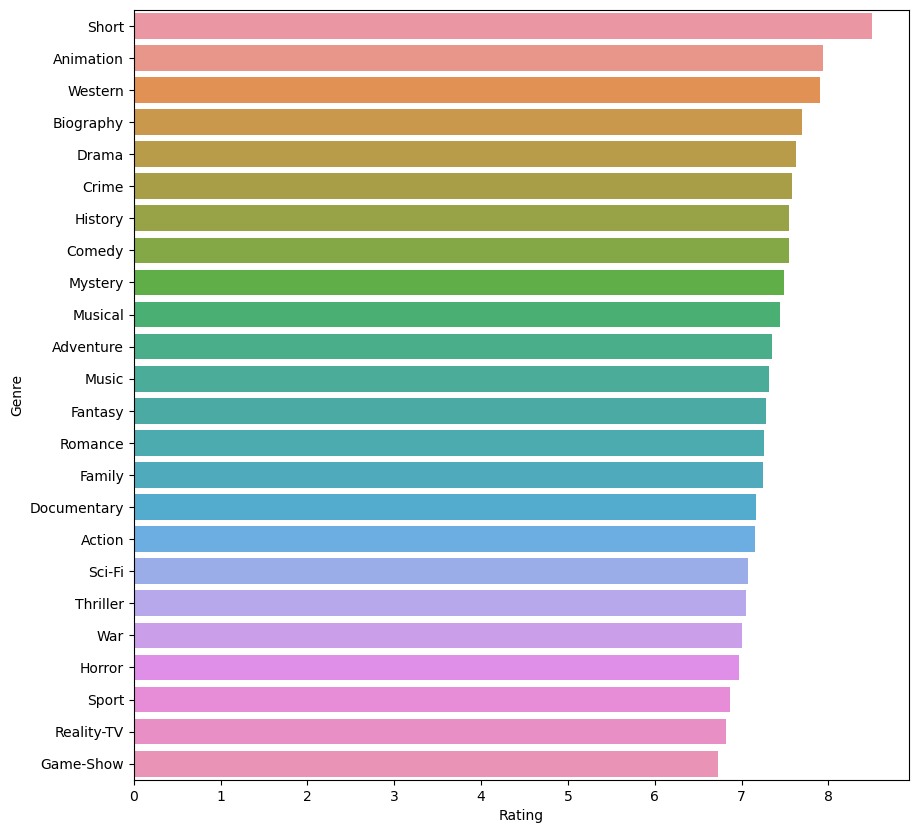

In [237]:
plt.figure(figsize=(10,10))
sns.barplot(data = pd.DataFrame(Rat2),x = 'Rating',y = 'Genre')
